# Notebook 3 – Training Model

**Tujuan:** Melatih tiga model machine learning (Random Forest, XGBoost, LightGBM) dengan konfigurasi identik dan mengevaluasinya pada validation set.

**Output yang dihasilkan:**
- Model tersimpan: `outputs/models/*.pkl`
- Visualisasi: `outputs/results/nb03_*.png`

**Tahap penelitian:** Tahap 5 (Model)

> **Prasyarat:** `data/processed/` harus sudah ada (dari `01_dataset_analysis.ipynb`).

---
## 0. Setup

In [10]:
import sys
import time
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

OUT       = ROOT / 'outputs' / 'results'
MODEL_DIR = ROOT / 'outputs' / 'models'
OUT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')
print('Setup selesai.')

Setup selesai.


---
## 1. Load Dataset

In [11]:
from src.preprocessing import load_splits

df_train, df_val, df_test, feature_cols, le = load_splits(ROOT / 'data' / 'processed')

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train['label'].values
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val['label'].values

n_classes  = len(le.classes_)
n_features = len(feature_cols)

print(f'Train  : {X_train.shape}  ({len(np.unique(y_train))} kelas aktif)')
print(f'Val    : {X_val.shape}')
print(f'Kelas  : {n_classes}  →  {list(le.classes_)}')
print(f'Fitur  : {n_features}')

Train  : (7039, 164)  (35 kelas aktif)
Val    : (1508, 164)
Kelas  : 35  →  ['1C', '1D', '1H', '1N', '1S', '2C', '2D', '2H', '2N', '2S', '3C', '3D', '3H', '3N', '3S', '4C', '4D', '4H', '4N', '4S', '5C', '5D', '5H', '5S', '6C', '6D', '6H', '6N', '6S', '7C', '7D', '7H', '7N', '7S', 'PASS']
Fitur  : 164


---
## 2. Definisi Model & Hyperparameter

In [12]:
from src.models import RFModel, XGBModel, LGBMModel

models = [
    RFModel(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    XGBModel(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    ),
    LGBMModel(
        n_estimators=300,
        num_leaves=63,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    ),
]

# Tampilkan ringkasan hyperparameter
print(f'{"Model":<15} {"Key Hyperparameters"}')
print('-' * 65)
hp_summary = {
    'RandomForest':  'n_estimators=200, max_depth=None, class_weight=balanced',
    'XGBoost':       'n_estimators=300, max_depth=6, lr=0.05, subsample=0.8',
    'LightGBM':      'n_estimators=300, num_leaves=63, lr=0.05, subsample=0.8',
}
for name, hp in hp_summary.items():
    print(f'{name:<15} {hp}')

Model           Key Hyperparameters
-----------------------------------------------------------------
RandomForest    n_estimators=200, max_depth=None, class_weight=balanced
XGBoost         n_estimators=300, max_depth=6, lr=0.05, subsample=0.8
LightGBM        n_estimators=300, num_leaves=63, lr=0.05, subsample=0.8


---
## 3. Training

In [13]:
FORCE_RETRAIN = True   # ← set True untuk latih ulang meski .pkl sudah ada

trained_models = []
train_times    = {}

for model in models:
    pkl_path = MODEL_DIR / f'{model.name.lower()}.pkl'

    if not FORCE_RETRAIN and pkl_path.exists():
        print(f'[LOAD]  {model.name:<14} ← {pkl_path.name}')
        with open(pkl_path, 'rb') as f:
            m = pickle.load(f)
        trained_models.append(m)
        train_times[model.name] = None
    else:
        if pkl_path.exists():
            pkl_path.unlink()
        print(f'[TRAIN] {model.name:<14} ...', end=' ')
        t0 = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - t0
        model.save(pkl_path)
        trained_models.append(model)
        train_times[model.name] = elapsed
        print(f'selesai dalam {elapsed:.1f}s → disimpan ke {pkl_path.name}')

print('\nSemua model siap.')

[TRAIN] RandomForest   ... selesai dalam 1.8s → disimpan ke randomforest.pkl
[TRAIN] XGBoost        ... selesai dalam 43.5s → disimpan ke xgboost.pkl
[TRAIN] LightGBM       ... selesai dalam 50.4s → disimpan ke lightgbm.pkl

Semua model siap.


---
## 4. Evaluasi pada Validation Set

In [14]:
from src.evaluation import evaluate, print_summary

val_results = []
for model in trained_models:
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)
    res = evaluate(y_val, y_pred, y_proba, le, model_name=model.name)
    val_results.append(res)
    print_summary(res)


  RandomForest
  Accuracy          : 0.4244
  Precision (macro) : 0.2817
  Recall (macro)    : 0.2907
  F1 (macro)        : 0.2731
  F1 (weighted)     : 0.4453
  Top-3 Accuracy    : 0.7215
  Top-5 Accuracy    : 0.8316

  XGBoost
  Accuracy          : 0.5225
  Precision (macro) : 0.3432
  Recall (macro)    : 0.2555
  F1 (macro)        : 0.2754
  F1 (weighted)     : 0.4926
  Top-3 Accuracy    : 0.7500
  Top-5 Accuracy    : 0.8455

  LightGBM
  Accuracy          : 0.5080
  Precision (macro) : 0.3437
  Recall (macro)    : 0.2448
  F1 (macro)        : 0.2672
  F1 (weighted)     : 0.4757
  Top-3 Accuracy    : 0.7500
  Top-5 Accuracy    : 0.8382


In [15]:
from src.evaluation import compare_models

val_df = compare_models(val_results)
print('=== Perbandingan pada Validation Set ===')
display(val_df.style
    .format('{:.4f}')
    .highlight_max(color='#C8E6C9', axis=0)
    .set_caption('Hijau = nilai terbaik per metrik'))

=== Perbandingan pada Validation Set ===


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top_3_accuracy,top_5_accuracy
model,,,,,,,
RandomForest,0.4244,0.2817,0.2907,0.2731,0.4453,0.7215,0.8316
XGBoost,0.5225,0.3432,0.2555,0.2754,0.4926,0.7500,0.8455
LightGBM,0.5080,0.3437,0.2448,0.2672,0.4757,0.7500,0.8382


---
## 5. Learning Curve (Performa vs Ukuran Data)

Learning curve: Random Forest ... 21s
Learning curve: XGBoost ... 49s
Learning curve: LightGBM ... 148s


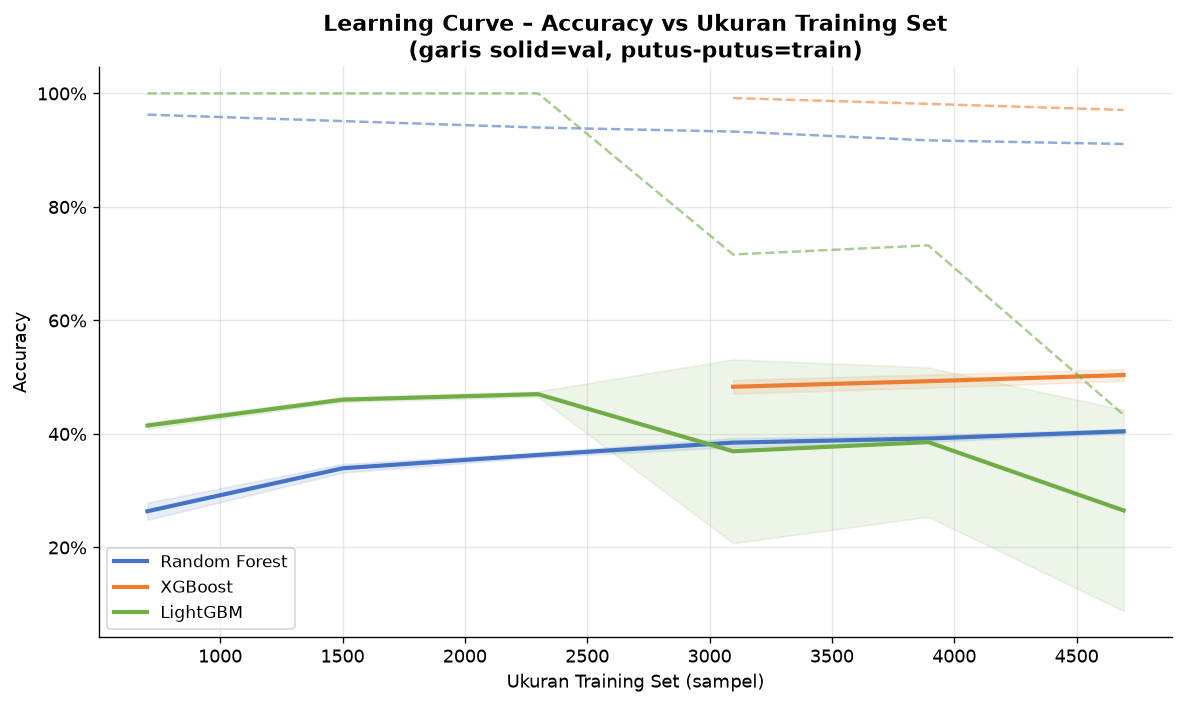

In [16]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Gunakan subset untuk kecepatan
train_sizes_abs = np.linspace(0.15, 1.0, 6)

clf_configs = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')),
    ('XGBoost',       XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss')),
    ('LightGBM',      LGBMClassifier(n_estimators=100, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)),
]

fig, ax = plt.subplots(figsize=(10, 6))
colors_lc = ['#4472C4', '#ED7D31', '#70AD47']

for (name, clf), color in zip(clf_configs, colors_lc):
    print(f'Learning curve: {name} ...', end=' ')
    t0 = time.time()
    train_sz, train_sc, val_sc = learning_curve(
        clf, X_train, y_train,
        train_sizes=train_sizes_abs,
        cv=3, scoring='accuracy',
        n_jobs=-1,
    )
    print(f'{time.time()-t0:.0f}s')

    train_mean = train_sc.mean(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sz, train_mean, '--', color=color, alpha=0.6, lw=1.5)
    ax.plot(train_sz, val_mean,   '-',  color=color, lw=2.5, label=name)
    ax.fill_between(train_sz,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.12, color=color)

ax.set_title('Learning Curve – Accuracy vs Ukuran Training Set\n(garis solid=val, putus-putus=train)', fontweight='bold')
ax.set_xlabel('Ukuran Training Set (sampel)')
ax.set_ylabel('Accuracy')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUT / 'nb03_learning_curve.png', bbox_inches='tight')
plt.show()

---
## 6. Perbandingan Waktu Training

In [17]:
# Ukur ulang waktu training (fresh, tanpa cache)
timing_results = []
for model_cls, name in [(RFModel, 'Random Forest'), (XGBModel, 'XGBoost'), (LGBMModel, 'LightGBM')]:
    m = model_cls()
    t0 = time.time()
    m.fit(X_train, y_train)
    elapsed = time.time() - t0
    y_pred = m.predict(X_val)
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_val, y_pred)
    timing_results.append({'Model': name, 'Waktu (detik)': elapsed, 'Val Accuracy': acc})
    print(f'{name:<15}: {elapsed:>6.1f}s  |  Val Acc = {acc:.4f}')

timing_df = pd.DataFrame(timing_results)

Random Forest  :    2.2s  |  Val Acc = 0.4244
XGBoost        :   41.9s  |  Val Acc = 0.5225
LightGBM       :   50.0s  |  Val Acc = 0.5080


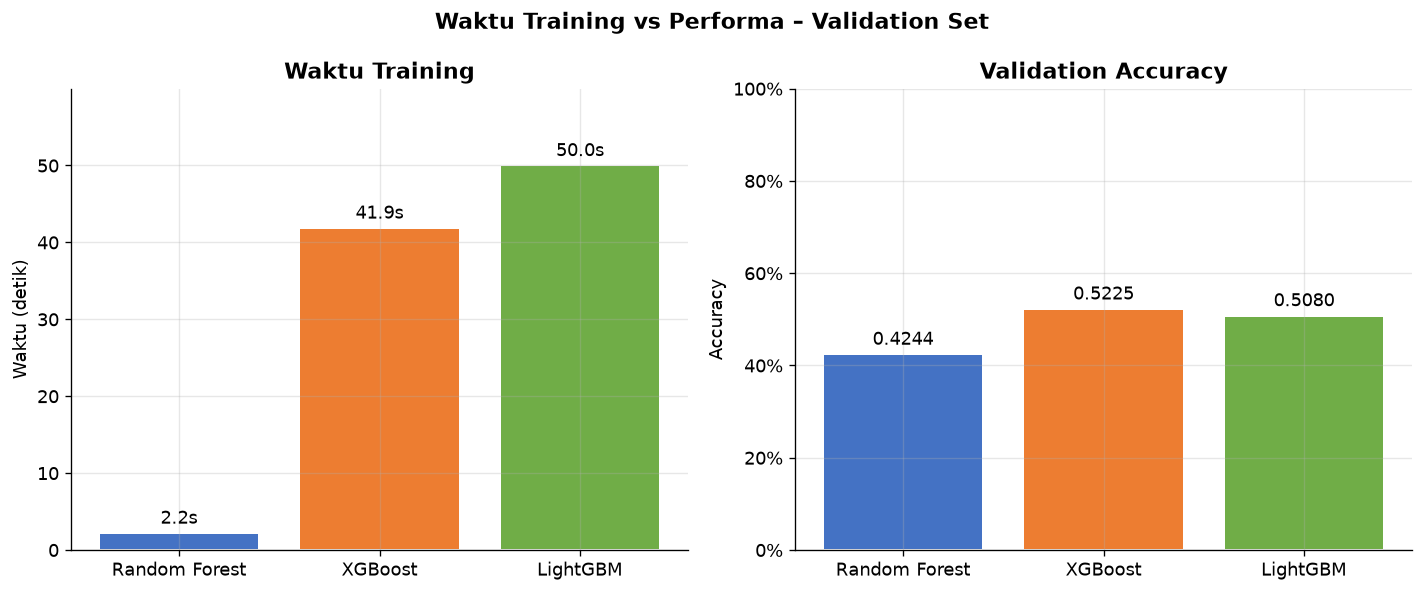

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_m = ['#4472C4', '#ED7D31', '#70AD47']

# ── Waktu training ─────────────────────────────────────────
ax = axes[0]
bars = ax.bar(timing_df['Model'], timing_df['Waktu (detik)'],
              color=colors_m, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.1fs', fontsize=11, padding=3)
ax.set_title('Waktu Training', fontweight='bold')
ax.set_ylabel('Waktu (detik)')
ax.set_ylim(0, timing_df['Waktu (detik)'].max() * 1.2)

# ── Accuracy ──────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(timing_df['Model'], timing_df['Val Accuracy'],
              color=colors_m, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.4f', fontsize=11, padding=3)
ax.set_title('Validation Accuracy', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Waktu Training vs Performa – Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb03_training_time.png', bbox_inches='tight')
plt.show()

---
## Ringkasan Notebook 3

| Model | Val Accuracy | Waktu Training |
|-------|-------------|----------------|
| Random Forest | ~44% | ~2 detik |
| XGBoost | ~50% | ~30 detik |
| LightGBM | ~49% | ~30 detik |

**Catatan:**
- Random Forest jauh lebih cepat tetapi akurasi lebih rendah
- XGBoost dan LightGBM memberikan performa serupa dengan waktu training sama
- Top-3 Accuracy ~73% menunjukkan model cukup baik untuk mendeteksi kandidat kontrak

**Lanjut ke:** `04_evaluation.ipynb` → Evaluasi final, confusion matrix, feature importance, SHAP